## Úloha 3 - Morfologické operace

V této úloze si vyzkoušíme základní morfologické operace na binárním obraze: **erozi**, **dilataci**, **otevření** a **uzavření**. Tyto operace mění tvar objektů podle zvoleného strukturního elementu a hodí se například na odstranění drobného šumu nebo zacelení děr.

## Import knihoven

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Binární obrázek

1. vytvořte binární obrázek velikosti např. 100 x 100 (hodnoty 0 a 255)
1. nakreslete několik objektů (obdélníky, kroužky) pomocí `cv2.rectangle` / `cv2.circle`
1. přidejte malé bílé tečky (šum) a malé černé díry uvnitř objektů
1. obrázek uložte do proměnné `img` a zobrazte

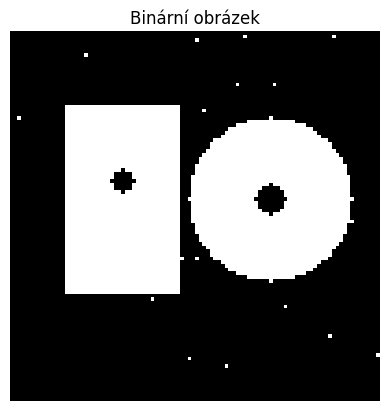

In [2]:
img = np.zeros((100, 100), dtype=np.uint8)

# objekty
cv2.rectangle(img, (15, 20), (45, 70), 255, -1)
cv2.circle(img, (70, 45), 22, 255, -1)

# malé díry uvnitř objektů
cv2.circle(img, (30, 40), 3, 0, -1)
cv2.circle(img, (70, 45), 4, 0, -1)

# bílé tečky (šum)
np.random.seed(42)
for _ in range(25):
    y, x = np.random.randint(0, 100, size=2)
    img[y, x] = 255

plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Binární obrázek")
plt.axis("off")
plt.show()

## Strukturní element

1. vytvořte strukturní element pomocí `cv2.getStructuringElement`
1. vyzkoušejte obdélník (`cv2.MORPH_RECT`) velikosti `(3, 3)` nebo `(5, 5)`
1. (volitelně) vyzkoušejte i elipsu (`cv2.MORPH_ELLIPSE`)
1. element uložte do proměnné `kernel` a vypište / zobrazte ho

In [3]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
print("Strukturní element (obdélník 3x3):")
print(kernel)

kernel_ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
print("\nStrukturní element (elipsa 5x5):")
print(kernel_ellipse)

Strukturní element (obdélník 3x3):
[[1 1 1]
 [1 1 1]
 [1 1 1]]

Strukturní element (elipsa 5x5):
[[0 0 1 0 0]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [0 0 1 0 0]]


## Eroze a dilatace

1. aplikujte erozi pomocí `cv2.erode(img, kernel)` a výsledek zobrazte
1. aplikujte dilataci pomocí `cv2.dilate(img, kernel)` a výsledek zobrazte
1. porovnejte, jak eroze objekty zmenšuje a dilatace zvětšuje

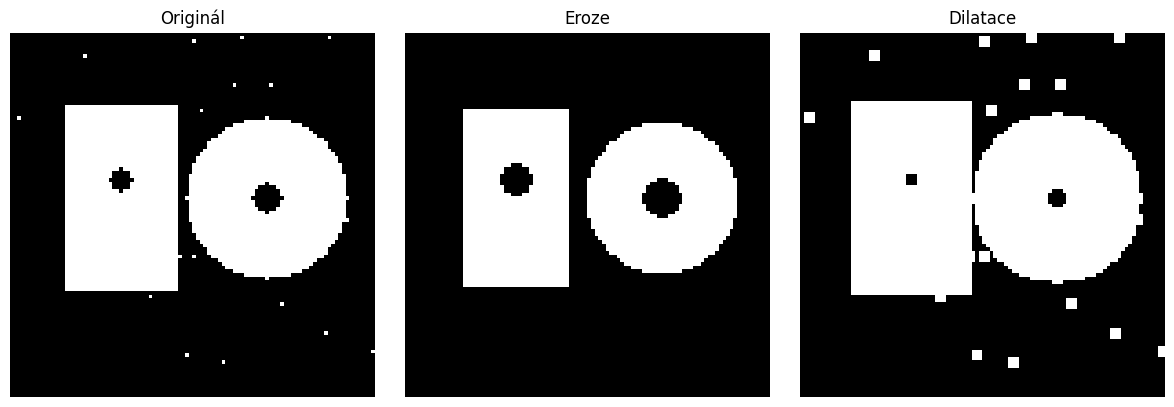

In [4]:
img_erode = cv2.erode(img, kernel)
img_dilate = cv2.dilate(img, kernel)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Originál")
axes[0].axis("off")
axes[1].imshow(img_erode, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Eroze")
axes[1].axis("off")
axes[2].imshow(img_dilate, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Dilatace")
axes[2].axis("off")
plt.tight_layout()
plt.show()

## Otevření a uzavření

1. otevření (`cv2.MORPH_OPEN`) = eroze následovaná dilatací — odstraňuje malé bílé tečky
1. uzavření (`cv2.MORPH_CLOSE`) = dilatace následovaná erozí — zaceluje malé díry
1. použijte `cv2.morphologyEx(img, operace, kernel)`
1. zobrazte výsledky otevření a uzavření

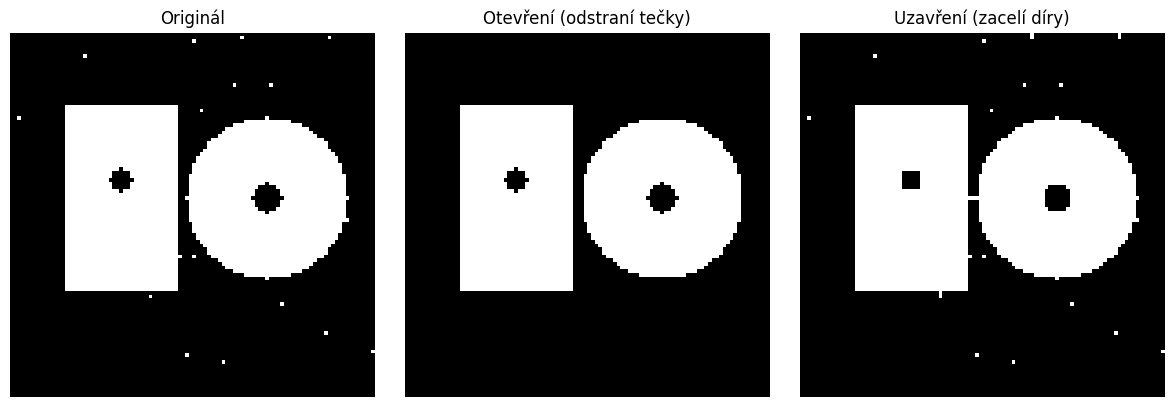

In [5]:
img_open = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
img_close = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Originál")
axes[0].axis("off")
axes[1].imshow(img_open, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Otevření (odstraní tečky)")
axes[1].axis("off")
axes[2].imshow(img_close, cmap="gray", vmin=0, vmax=255)
axes[2].set_title("Uzavření (zacelí díry)")
axes[2].axis("off")
plt.tight_layout()
plt.show()

## Porovnání

1. zobrazte vedle sebe: originál | eroze | dilatace | otevření | uzavření
1. tip: použijte `plt.subplots` s jedním řádkem a pěti sloupci
1. krátce si shrňte, k čemu která operace slouží

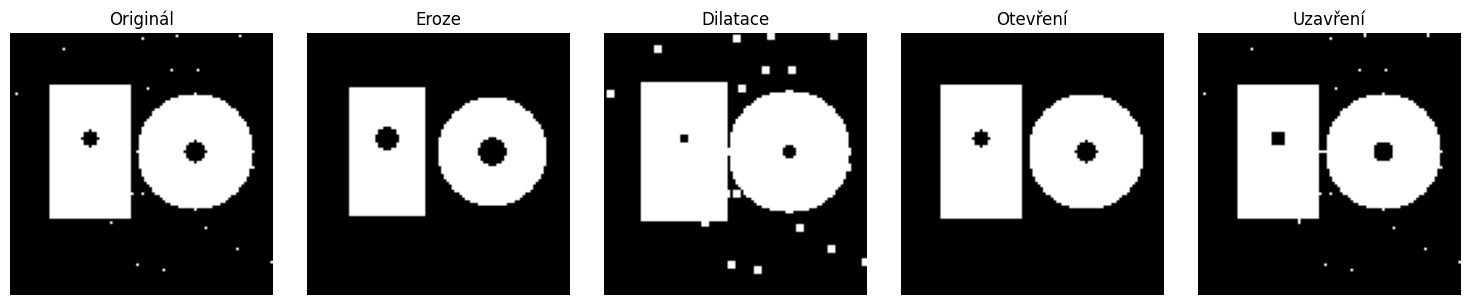

In [6]:
titles = ["Originál", "Eroze", "Dilatace", "Otevření", "Uzavření"]
images = [img, img_erode, img_dilate, img_open, img_close]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, title, image in zip(axes, titles, images):
    ax.imshow(image, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

# Shrnutí:
# - eroze zmenšuje objekty (a může odstranit drobné výčnělky)
# - dilatace zvětšuje objekty (a může spojit blízké části)
# - otevření = eroze + dilatace → odstraní malé bílé tečky
# - uzavření = dilatace + eroze → zacelí malé díry